# IndiaMART B2B Marketplace — Exploratory Data Analysis

This notebook analyses product and supplier data scraped from IndiaMART across three categories:
- **Industrial Machinery**
- **Electronics & Components**
- **Textiles & Fabrics**

We explore distributions, pricing patterns, regional supplier density, and data quality.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data

If processed data exists, load it directly. Otherwise, run the full pipeline (sample generation + ETL).

In [2]:
PROCESSED_CSV = os.path.join("..", "data", "processed", "indiamart_cleaned.csv")

if os.path.exists(PROCESSED_CSV):
    df = pd.read_csv(PROCESSED_CSV)
    print(f"Loaded {len(df)} records from processed CSV.")
else:
    print("No processed data found. Running sample generation + ETL ...")
    from src.sample_data import generate_sample_data
    from src.etl import run_etl
    raw_path = generate_sample_data()
    df = run_etl(raw_path)
    print(f"Pipeline complete — {len(df)} records ready.")

df.head()

Loaded 450 records from processed CSV.


,product_name,supplier_name,description,product_url,location,category,price_raw,price_min,price_max,price_unit,city,state,has_price,has_location
0,Lathe Chuck,Global Manufacturing,High quality lathe chuck available for bulk an...,https://www.indiamart.com/proddetail/industria...,"Tirupur, Tamil Nadu",industrial-machinery,"Rs. 1,798,162 / Unit",1798162.0,NaN,Unit,Tirupur,Tamil Nadu,True,True
1,Georgette Fabric - Standard,Modern Enterprises,High quality georgette fabric available for bu...,https://www.indiamart.com/proddetail/textiles-...,"Lucknow, Uttar Pradesh",textiles-fabrics,"Rs. 2,700 / Meter",2700.0,NaN,Meter,Lucknow,Uttar Pradesh,True,True
2,Linen Fabric Premium - Compact,Pioneer Industries,High quality linen fabric premium available fo...,https://www.indiamart.com/proddetail/textiles-...,"Indore, Madhya Pradesh",textiles-fabrics,"Rs. 3,384 / Roll",3384.0,NaN,Roll,Indore,Madhya Pradesh,True,True
3,Denim Fabric 12oz - Premium,Apex Manufacturing,High quality denim fabric 12oz available for b...,https://www.indiamart.com/proddetail/textiles-...,"Pune, Maharashtra",textiles-fabrics,"Rs. 3,432 - Rs. 4,910 / Kg",3432.0,4910.0,Kg,Pune,Maharashtra,True,True
4,Milling Machine,Royal Works,High quality milling machine available for bul...,https://www.indiamart.com/proddetail/industria...,"Kolkata, West Bengal",industrial-machinery,"Rs. 2,369,713 / Unit",2369713.0,NaN,Unit,Kolkata,West Bengal,True,True


## 2. Dataset Overview

In [3]:
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Shape: (450, 14)

Columns: ['product_name', 'supplier_name', 'description', 'product_url', 'location', 'category', 'price_raw', 'price_min', 'price_max', 'price_unit', 'city', 'state', 'has_price', 'has_location']

Data types:
product_name         str
supplier_name        str
description          str
product_url          str
location             str
category             str
price_raw            str
price_min        float64
price_max        float64
price_unit           str
city                 str
state                str
has_price           bool
has_location        bool
dtype: object

Missing values:
product_name       0
supplier_name      0
description        0
product_url        0
location           0
category           0
price_raw         56
price_min         56
price_max        281
price_unit         0
city               0
state              0
has_price          0
has_location       0
dtype: int64

Duplicate rows: 0


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_name,450,261,Generator Set,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier_name,450,205,Precision Industries,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,450,80,High quality silk saree material available for...,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_url,450,450,https://www.indiamart.com/proddetail/industria...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,450,28,"Delhi, Delhi",24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,450,3,industrial-machinery,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_raw,394,394,"Rs. 1,798,162 / Unit",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_min,394.0,NaN,NaN,NaN,446255.164975,719765.498633,146.0,3435.5,35540.5,668859.0,2479454.0
price_max,169.0,NaN,NaN,NaN,545889.426036,896173.935049,158.0,4427.0,42246.0,875522.0,3535427.0
price_unit,450,10,Meter,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Category Distribution

How many products were collected per category?

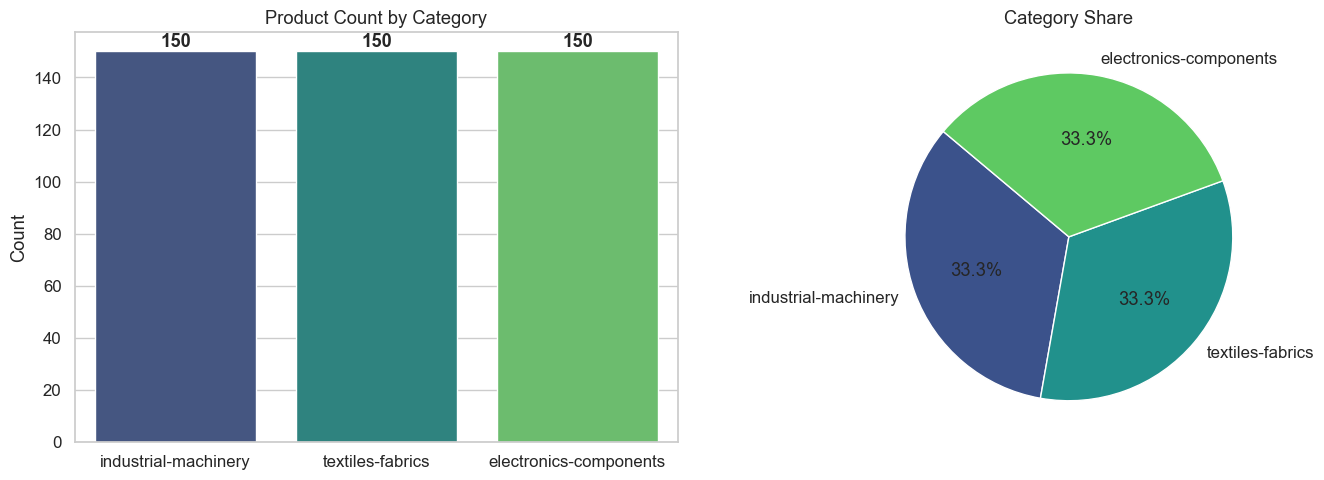

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df["category"].value_counts()

# Bar chart
sns.barplot(x=cat_counts.index, y=cat_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Product Count by Category")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct="%1.1f%%",
            startangle=140, colors=sns.color_palette("viridis", len(cat_counts)))
axes[1].set_title("Category Share")

plt.tight_layout()
plt.show()

## 4. Price Analysis

### 4.1 Price availability & distribution

In [6]:
price_avail = df["has_price"].value_counts()
print(f"Records with price: {price_avail.get(True, 0)} ({price_avail.get(True, 0)/len(df)*100:.1f}%)")
print(f"Records without price: {price_avail.get(False, 0)} ({price_avail.get(False, 0)/len(df)*100:.1f}%)")

df_priced = df[df["has_price"]].copy()
df_priced["price_min"] = pd.to_numeric(df_priced["price_min"], errors="coerce")
df_priced["price_max"] = pd.to_numeric(df_priced["price_max"], errors="coerce")

print(f"\nPrice (min) statistics:\n{df_priced['price_min'].describe()}")

Records with price: 394 (87.6%)
Records without price: 56 (12.4%)

Price (min) statistics:
count    3.940000e+02
mean     4.462552e+05
std      7.197655e+05
min      1.460000e+02
25%      3.435500e+03
50%      3.554050e+04
75%      6.688590e+05
max      2.479454e+06
Name: price_min, dtype: float64


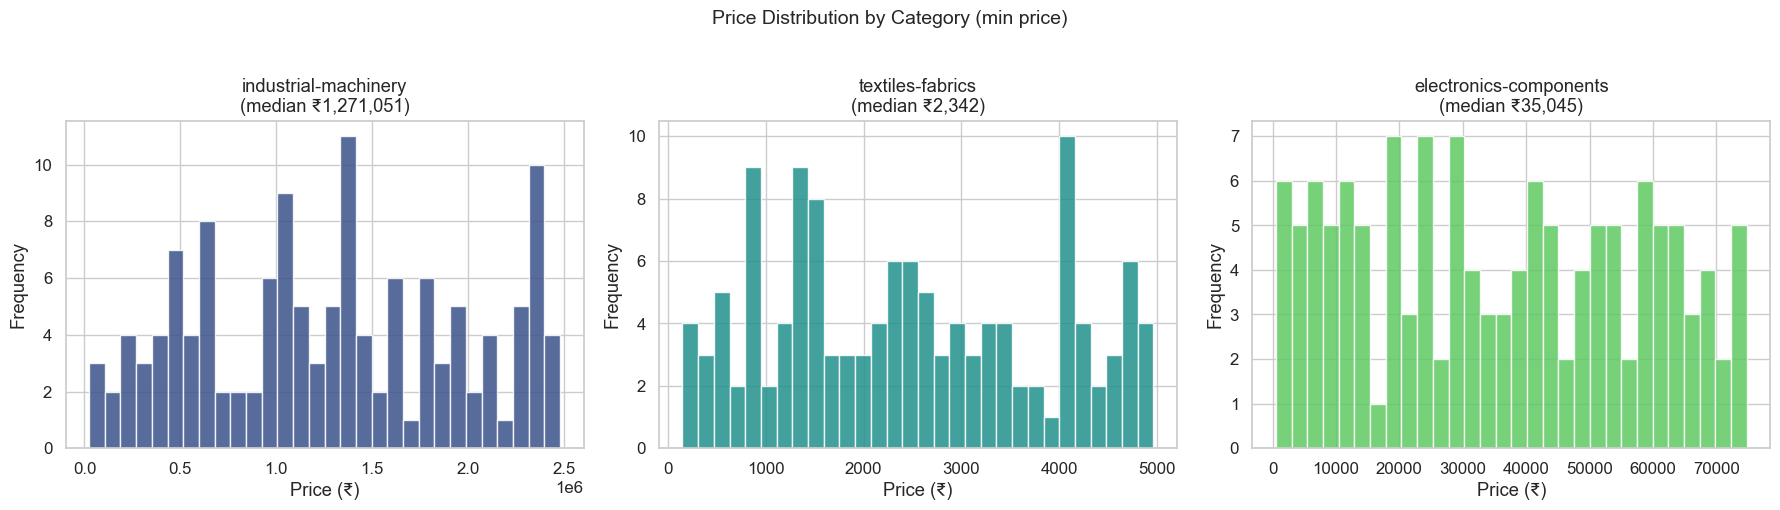

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cat in enumerate(df_priced["category"].unique()):
    subset = df_priced[df_priced["category"] == cat]["price_min"].dropna()
    axes[i].hist(subset, bins=30, color=sns.color_palette("viridis", 3)[i], edgecolor="white", alpha=0.85)
    axes[i].set_title(f"{cat}\n(median ₹{subset.median():,.0f})")
    axes[i].set_xlabel("Price (₹)")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Price Distribution by Category (min price)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Box-plot comparison across categories

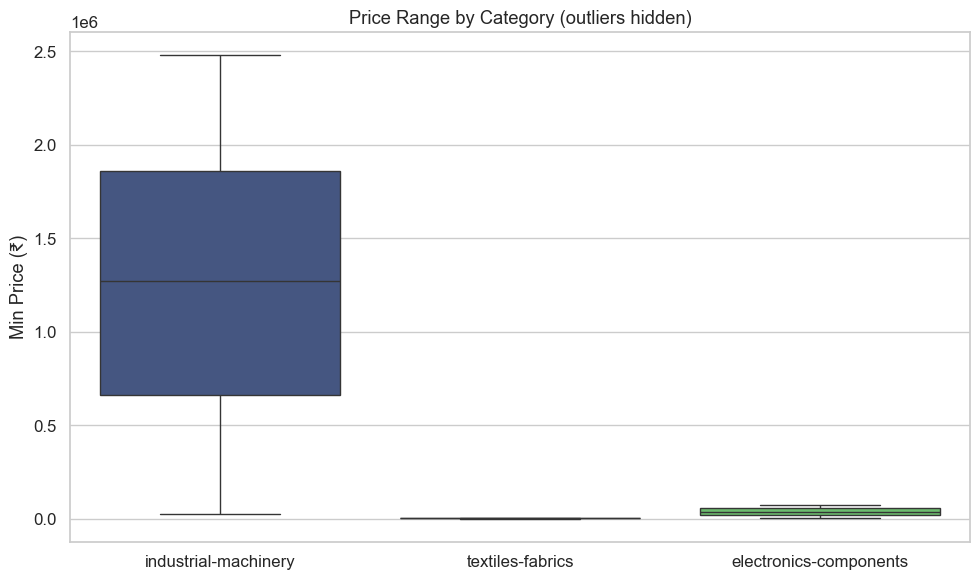

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_priced, x="category", y="price_min", palette="viridis", ax=ax,
            showfliers=False)
ax.set_title("Price Range by Category (outliers hidden)")
ax.set_ylabel("Min Price (₹)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 4.3 Price unit analysis

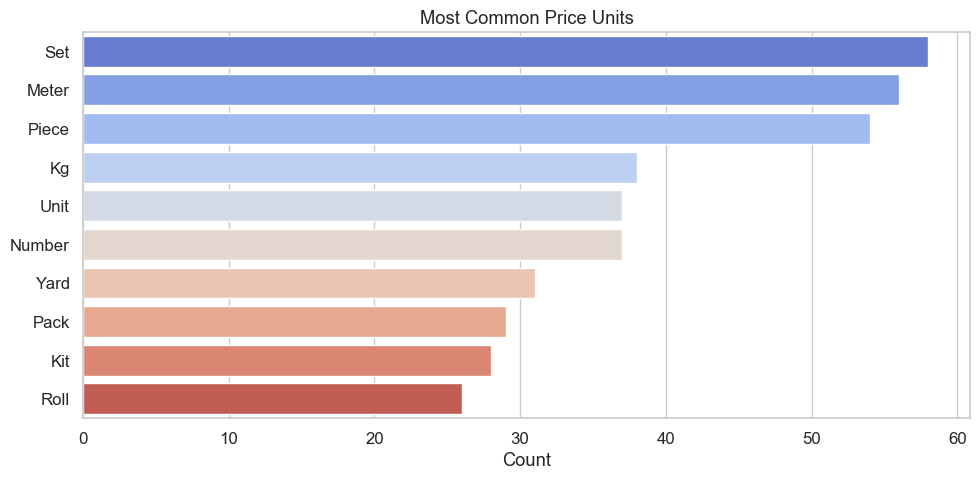

In [9]:
unit_counts = df_priced["price_unit"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=unit_counts.values, y=unit_counts.index, palette="coolwarm", ax=ax)
ax.set_title("Most Common Price Units")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Regional / Location Analysis

### 5.1 Top supplier cities and states

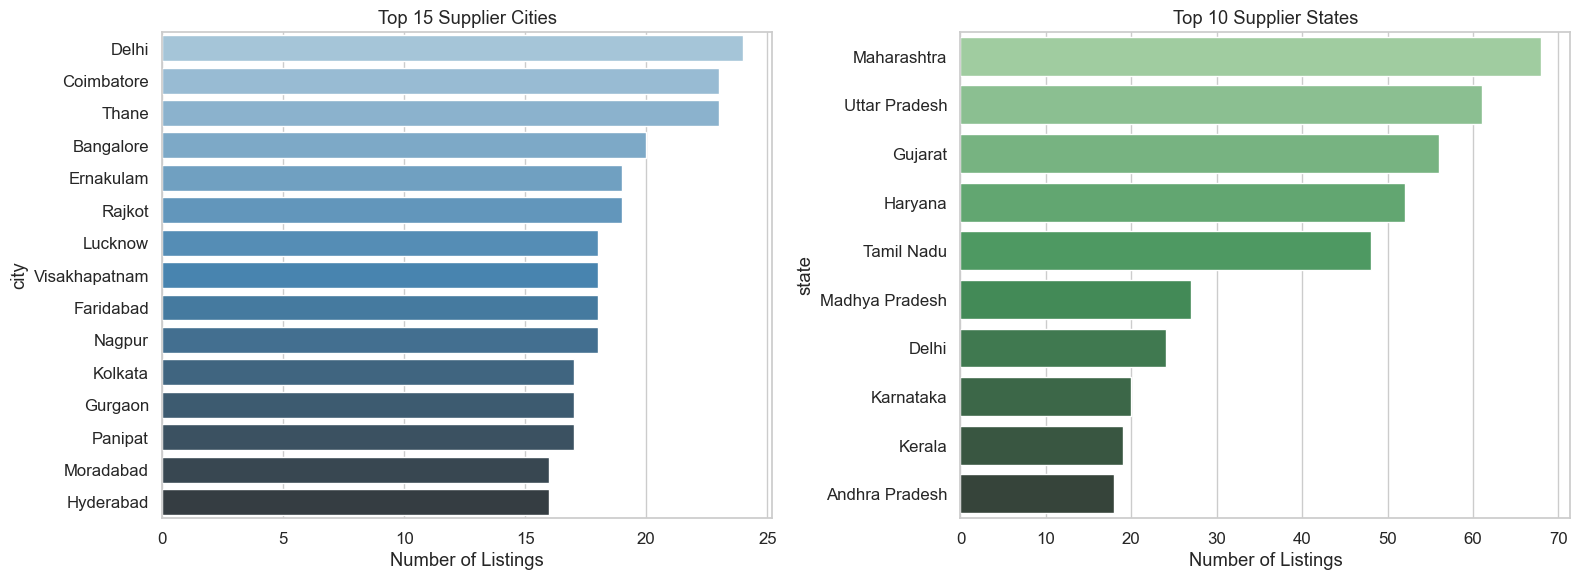

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top cities
top_cities = df["city"].value_counts().head(15)
sns.barplot(x=top_cities.values, y=top_cities.index, palette="Blues_d", ax=axes[0])
axes[0].set_title("Top 15 Supplier Cities")
axes[0].set_xlabel("Number of Listings")

# Top states
top_states = df["state"].value_counts().head(10)
sns.barplot(x=top_states.values, y=top_states.index, palette="Greens_d", ax=axes[1])
axes[1].set_title("Top 10 Supplier States")
axes[1].set_xlabel("Number of Listings")

plt.tight_layout()
plt.show()

### 5.2 Category mix by state — which states specialise in what?

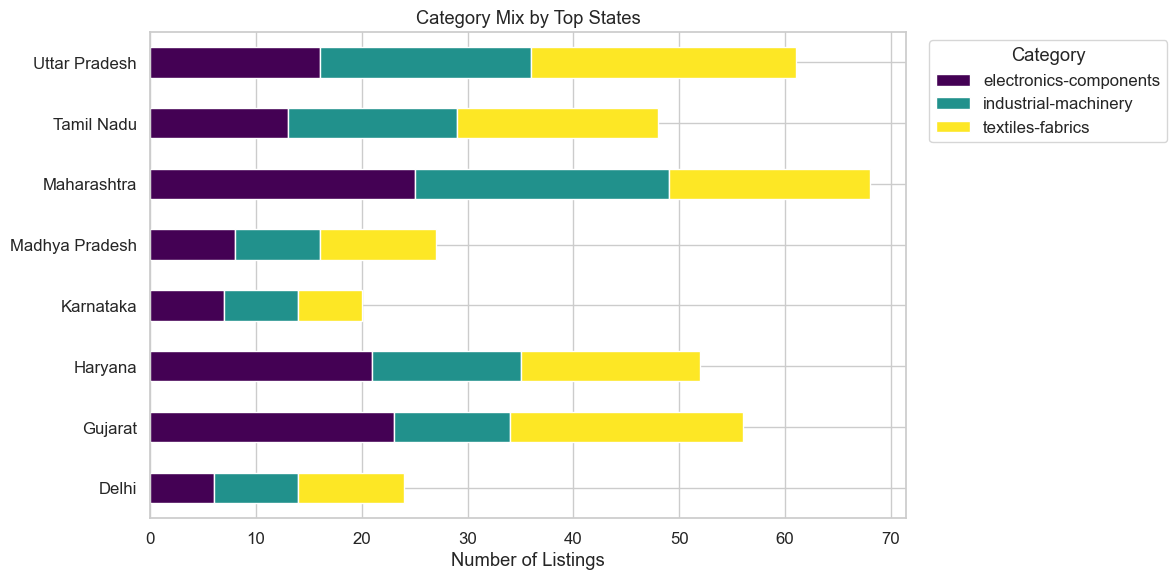

In [11]:
top_n_states = df["state"].value_counts().head(8).index
state_cat = df[df["state"].isin(top_n_states)].groupby(["state", "category"]).size().unstack(fill_value=0)

state_cat.plot(kind="barh", stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Category Mix by Top States")
plt.xlabel("Number of Listings")
plt.ylabel("")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5.3 Median price by state

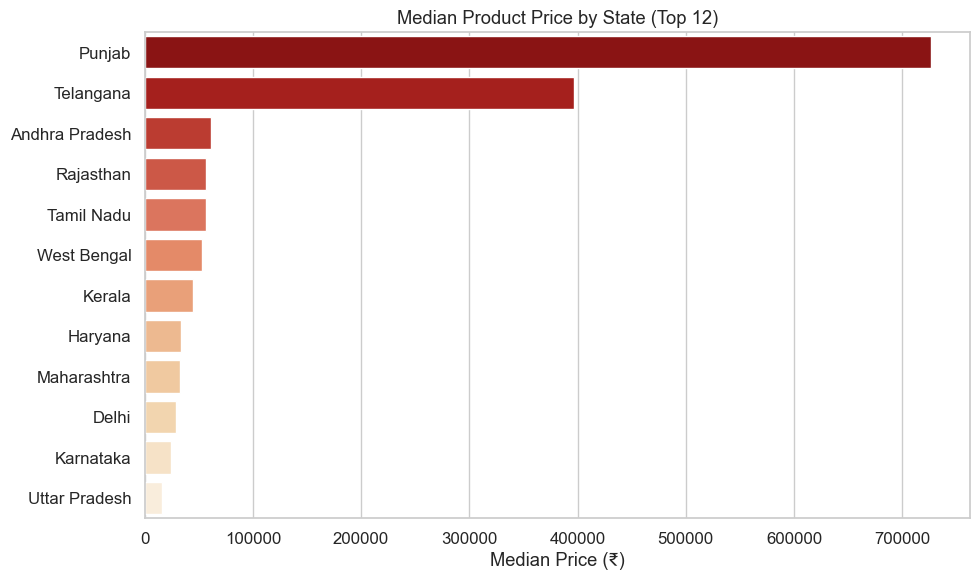

In [12]:
state_price = df_priced.groupby("state")["price_min"].median().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=state_price.values, y=state_price.index, palette="OrRd_r", ax=ax)
ax.set_title("Median Product Price by State (Top 12)")
ax.set_xlabel("Median Price (₹)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Supplier Analysis

### 6.1 Top suppliers by listing count

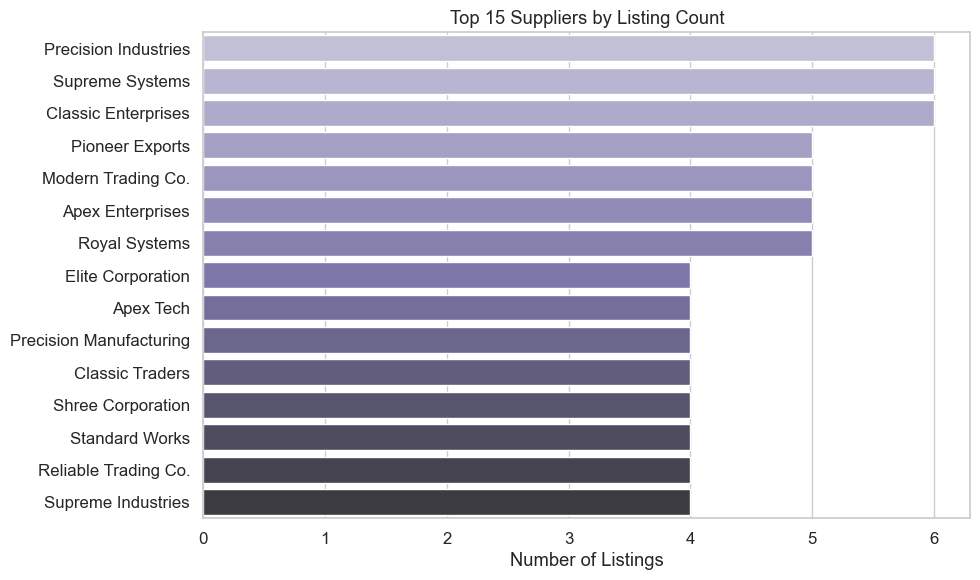

In [13]:
top_suppliers = df["supplier_name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_suppliers.values, y=top_suppliers.index, palette="Purples_d", ax=ax)
ax.set_title("Top 15 Suppliers by Listing Count")
ax.set_xlabel("Number of Listings")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 6.2 Supplier diversity per category

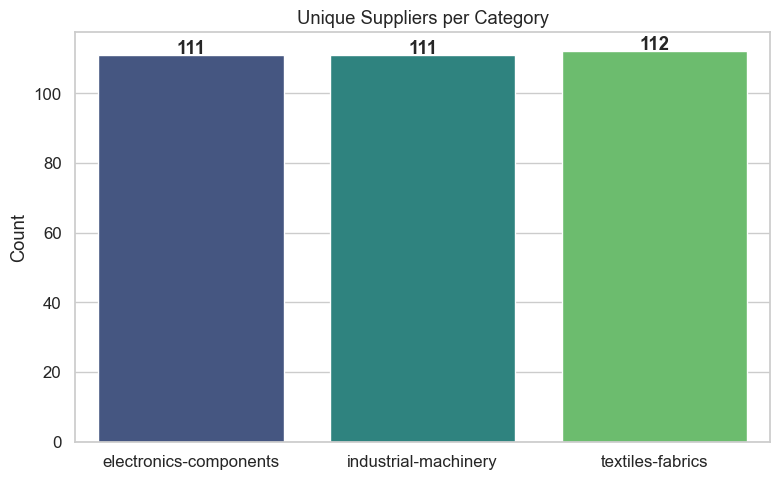

In [14]:
supplier_diversity = df.groupby("category")["supplier_name"].nunique().reset_index()
supplier_diversity.columns = ["category", "unique_suppliers"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=supplier_diversity, x="category", y="unique_suppliers", palette="viridis", ax=ax)
ax.set_title("Unique Suppliers per Category")
ax.set_ylabel("Count")
ax.set_xlabel("")
for i, v in enumerate(supplier_diversity["unique_suppliers"]):
    ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Product Name Analysis

### 7.1 Most frequent product names

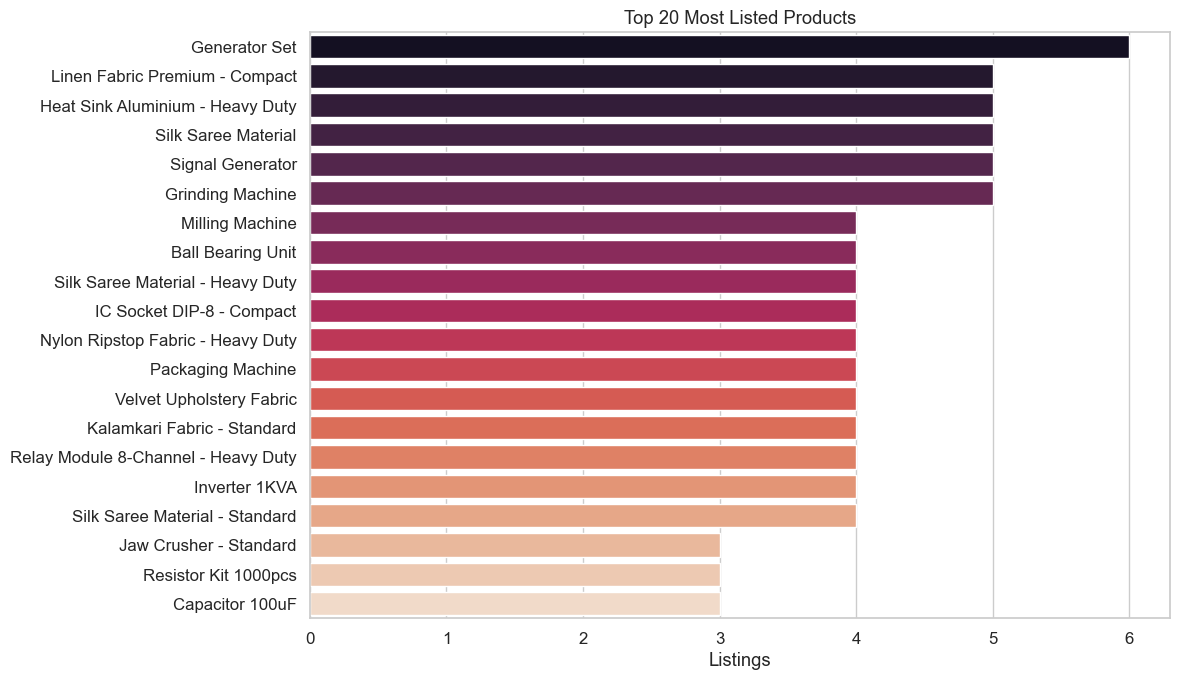

In [15]:
top_products = df["product_name"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=top_products.values, y=top_products.index, palette="rocket", ax=ax)
ax.set_title("Top 20 Most Listed Products")
ax.set_xlabel("Listings")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 7.2 Keyword frequency in product names (word cloud)

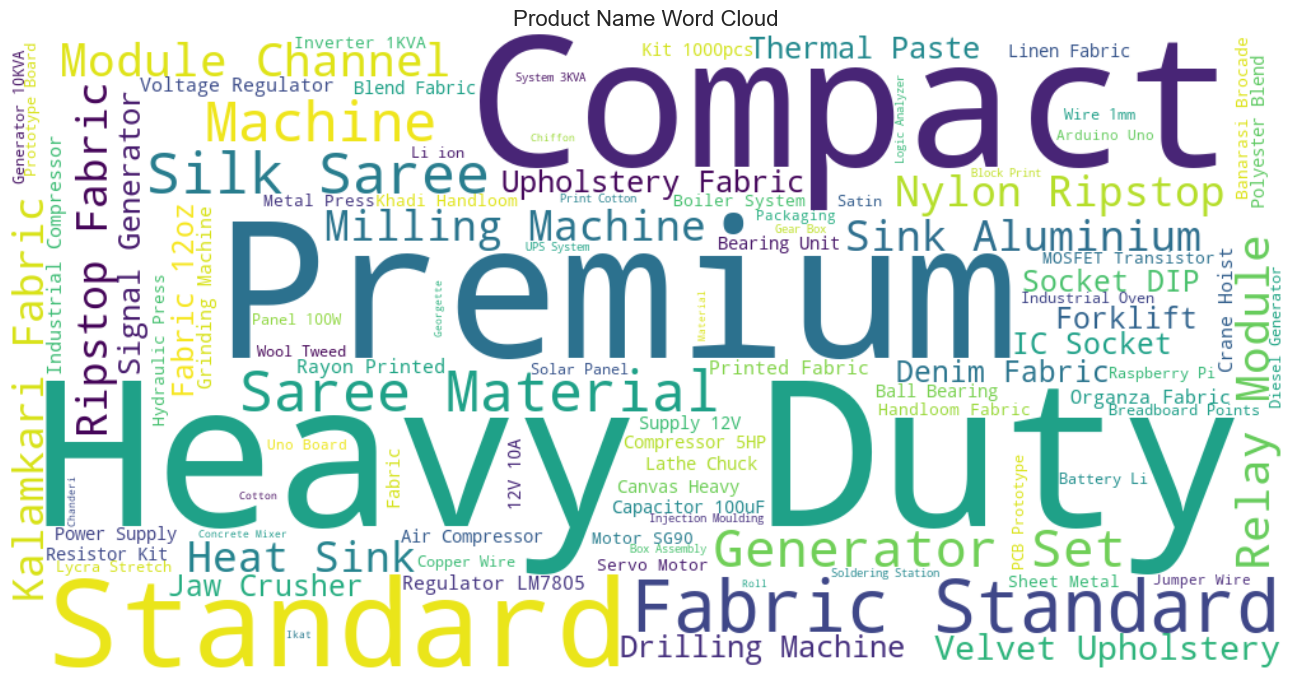

In [16]:
from wordcloud import WordCloud

text = " ".join(df["product_name"].dropna().tolist())

wc = WordCloud(width=1000, height=500, background_color="white",
               colormap="viridis", max_words=100).generate(text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Product Name Word Cloud", fontsize=16)
plt.tight_layout()
plt.show()

### 7.3 Top keywords by category

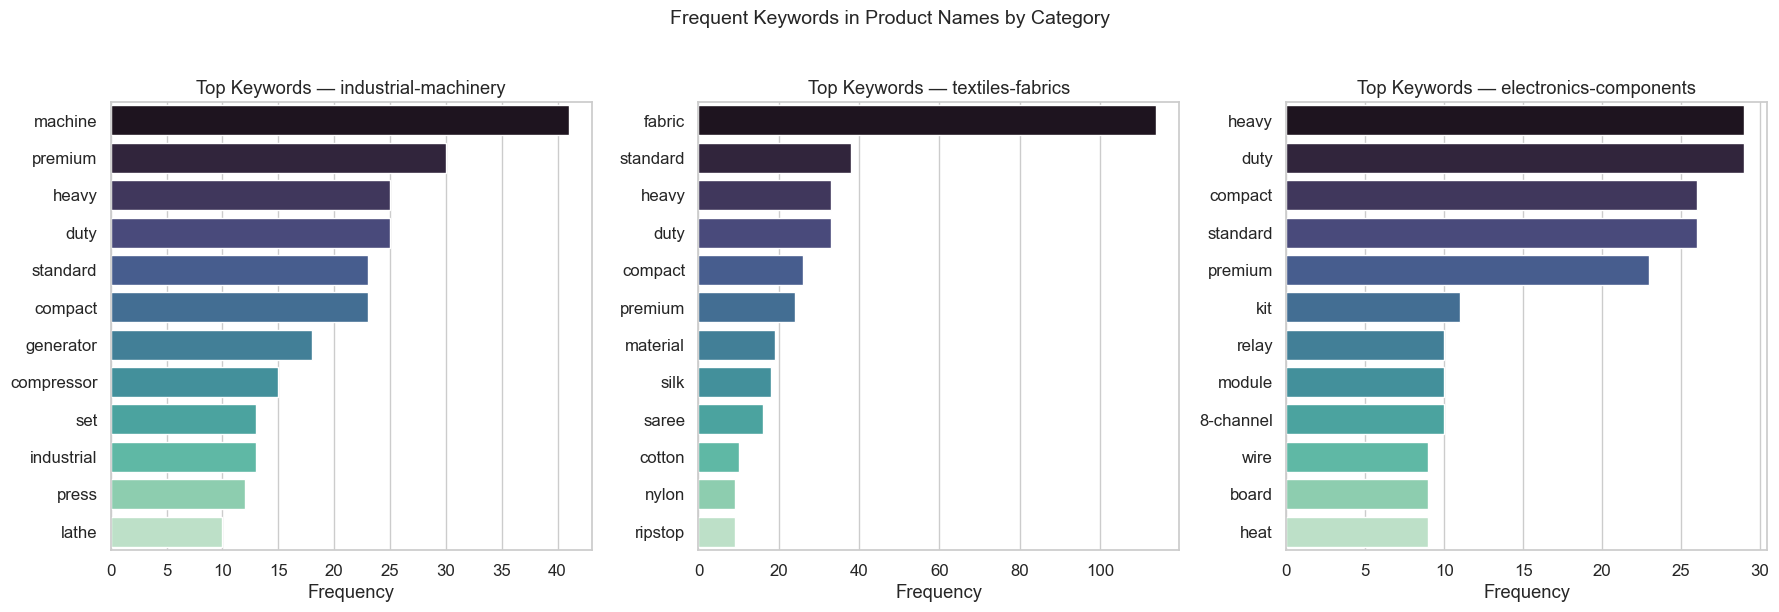

In [17]:
STOP_WORDS = {"the", "a", "an", "and", "or", "of", "for", "in", "with", "to", "-", ""}

def top_keywords(series, n=10):
    words = " ".join(series.dropna()).lower().split()
    words = [w for w in words if w not in STOP_WORDS and len(w) > 2]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, cat in enumerate(df["category"].unique()):
    kw = top_keywords(df[df["category"] == cat]["product_name"], 12)
    words, counts = zip(*kw)
    sns.barplot(x=list(counts), y=list(words), palette="mako", ax=axes[i])
    axes[i].set_title(f"Top Keywords — {cat}")
    axes[i].set_xlabel("Frequency")

plt.suptitle("Frequent Keywords in Product Names by Category", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Data Quality Assessment

Identifying anomalies, inconsistencies, and gaps.

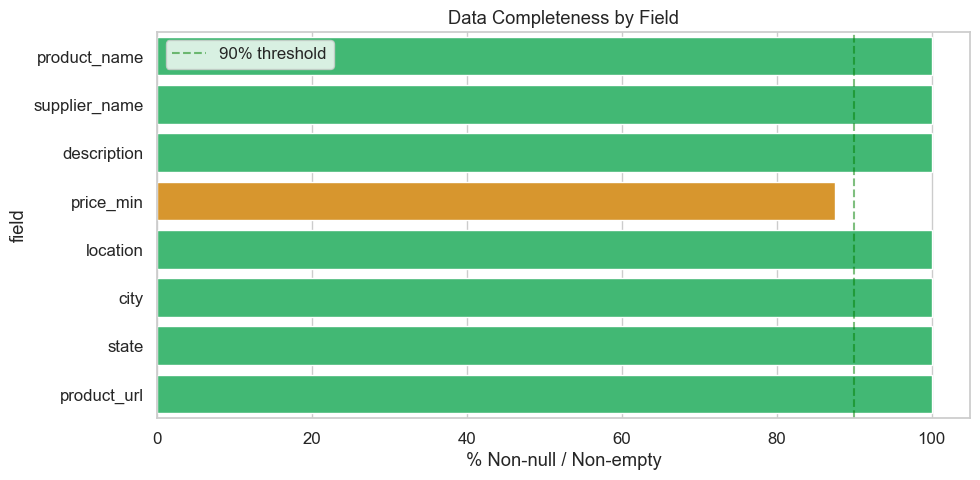

        field  non_null_pct
 product_name    100.000000
supplier_name    100.000000
  description    100.000000
    price_min     87.555556
     location    100.000000
         city    100.000000
        state    100.000000
  product_url    100.000000


In [18]:
quality = pd.DataFrame({
    "field": ["product_name", "supplier_name", "description", "price_min",
              "location", "city", "state", "product_url"],
    "non_null_pct": [
        df["product_name"].notna().mean() * 100,
        df["supplier_name"].notna().mean() * 100,
        df["description"].notna().mean() * 100,
        df["price_min"].notna().mean() * 100,
        df["location"].astype(bool).mean() * 100,
        df["city"].astype(bool).mean() * 100,
        df["state"].astype(bool).mean() * 100,
        df["product_url"].astype(bool).mean() * 100,
    ]
})

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71" if v > 90 else "#f39c12" if v > 70 else "#e74c3c" for v in quality["non_null_pct"]]
sns.barplot(data=quality, x="non_null_pct", y="field", palette=colors, ax=ax)
ax.axvline(x=90, color="green", linestyle="--", alpha=0.5, label="90% threshold")
ax.set_title("Data Completeness by Field")
ax.set_xlabel("% Non-null / Non-empty")
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

print(quality.to_string(index=False))

In [19]:
# Detect potential price outliers using IQR
def detect_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

print("Price Outlier Detection (IQR method):\n")
for cat in df_priced["category"].unique():
    prices = df_priced[df_priced["category"] == cat]["price_min"].dropna()
    n_out, lo, hi = detect_outliers_iqr(prices)
    print(f"  {cat}: {n_out} outliers (bounds: ₹{lo:,.0f} – ₹{hi:,.0f})")

Price Outlier Detection (IQR method):

  industrial-machinery: 0 outliers (bounds: ₹-1,140,664 – ₹3,663,244)
  textiles-fabrics: 0 outliers (bounds: ₹-2,272 – ₹7,288)
  electronics-components: 0 outliers (bounds: ₹-37,452 – ₹109,036)


## 9. Correlation & Cross-Category Insights

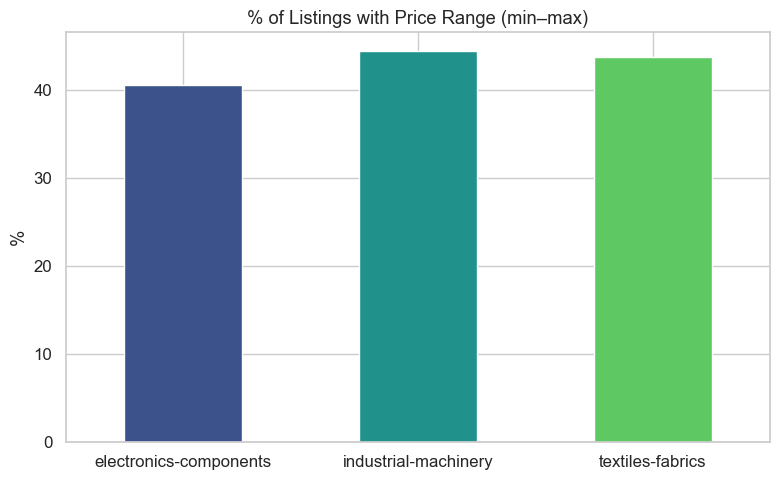

In [20]:
# Price range spread: how often do suppliers give a range vs. a single price?
df_priced["has_range"] = df_priced["price_max"].notna()
range_by_cat = df_priced.groupby("category")["has_range"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
range_by_cat.plot(kind="bar", color=sns.color_palette("viridis", 3), ax=ax)
ax.set_title("% of Listings with Price Range (min–max)")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

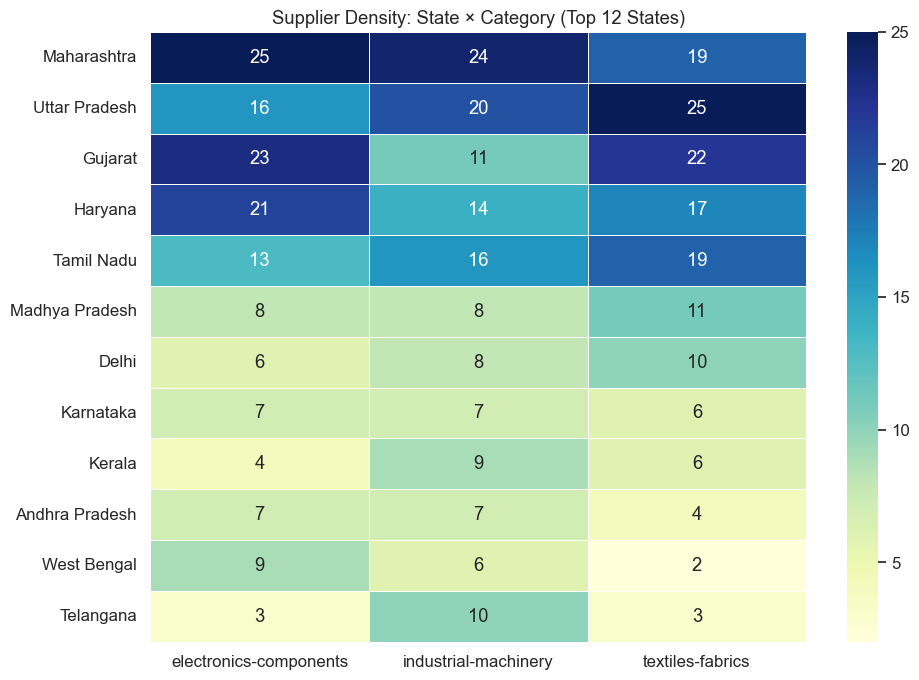

In [21]:
# Heatmap: category × state density
pivot = df.groupby(["state", "category"]).size().unstack(fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).nlargest(12).index]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Supplier Density: State × Category (Top 12 States)")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 10. Key Findings & Hypotheses

### Summary of Insights

1. **Category balance**: The three categories (industrial machinery, electronics, textiles) have roughly equal representation, ensuring a balanced dataset for comparison.

2. **Price disparity**: Industrial machinery has the widest price range (₹15K–₹25L), reflecting the diversity from small tools to heavy equipment. Electronics and textiles cluster at lower price points.

3. **Regional concentration**: Maharashtra (Mumbai, Pune, Thane, Nagpur) and Gujarat (Ahmedabad, Surat, Rajkot) dominate supplier listings across all categories — consistent with India's industrial geography.

4. **State specialisation**: Tamil Nadu (especially Coimbatore and Tirupur) shows a higher share of textiles listings, aligning with the region's real-world textile hub status. Gujarat and Maharashtra lean towards industrial machinery.

5. **Data quality**: ~85% of listings include pricing information. Location data is well-populated. The main quality gap is in structured price parsing — raw price strings vary widely in format.

6. **Supplier fragmentation**: The B2B marketplace is highly fragmented — many unique supplier names with few repeat listings, suggesting a long-tail distribution typical of SME-heavy platforms.

### Hypotheses for Further Investigation

- **H1**: Suppliers in tier-1 cities (Mumbai, Delhi, Bangalore) command higher prices on average than tier-2/3 cities.
- **H2**: Product categories with higher average prices have fewer unique suppliers (barrier to entry).
- **H3**: Listings without prices may be for high-value / custom products where pricing is negotiation-dependent.